# Week Two GPT-2 Small Greater than Capability Analysis

The second week of this project will focus on path patching, circuit diagramming, and an indepth analysis of what information is being communicated between components in the circuit. From our results in week one, we found hypothesize that layers 5, 7, and 8 all contribute to MLP 9. To confirm or falsify this idea we will perform targeted path patching of the attention outputs of these layers with MLP 9. Ultimately our goal is to end this week with a concrete diagram of what is included in the greater than circuit.

In [3]:
# Set project root
import sys
sys.path.append("/Users/benjawesome/coding/greater-than-cap-analysis")

In [4]:
# For saving files
import os
os.chdir("/Users/benjawesome/coding/greater-than-cap-analysis")

import textwrap

In [5]:
# Imports and device....

import torch
import torch.nn.functional as F

device = torch.device('mps')

In [6]:
# More imports...

# Transformer lens and GPT2-Small
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2-small", device=device)

# Import our prompt generation script and create 50 prompts
from data.greater_than_prompt_generation import generate_dataset
from data.greater_than_prompt_generation import generate_full_dataset

all_prompts = generate_full_dataset()

import matplotlib.pyplot as plt

/Users/benjawesome/coding/greater-than-cap-analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer


In [7]:
# Separate prompts into whether they are 8 or 9 tokens

short_prompts = []
long_prompts = []

for prompt, num in all_prompts:
    tokens = model.to_tokens(prompt)
    if (tokens.size(-1) == 12):
        short_prompts.append((prompt, num))
    else:
        long_prompts.append((prompt, num))

In [8]:
# Get initial model accuracy

correct_one = 0
correct_two = 0

# Get baseline accuracies
for prompt, num in short_prompts:
    # Get model prediction
    tokens = model.to_tokens(prompt)
    logits, _ = model.run_with_cache(tokens)
    prediction = logits[0, -1].argmax()

    try:
        prediction = int(model.to_string(prediction))
        if (prediction > num):
            correct_one += 1
    except ValueError:
        pass

print("Accuracy of eight token prompts is " + str(correct_one) + " out of 20")

for prompt, num in long_prompts:
    # Get model prediction
    tokens = model.to_tokens(prompt)
    logits, _ = model.run_with_cache(tokens)
    prediction = logits[0, -1].argmax()

    try:
        prediction = int(model.to_string(prediction))
        if (prediction > num):
            correct_two += 1
    except ValueError:
        pass

print("Accuracy of eight token prompts is " + str(correct_two) + " out of 79")

Accuracy of eight token prompts is 15 out of 20
Accuracy of eight token prompts is 79 out of 79


## Path Patching

Our first path patching experiment will be on the direct contribution to the logits. This will help us confirm our results from the ablation tests of which components are important to the circuit. Afterwards, we will path patch paths through these important components to identify what components contribute to the greater than computation via indirect routes.

Furthermore, we must change our measured metric. The original paper takes the difference between the probability that the predicted year is greater than XX and the probability that the predicted year is less than or equal to XX.

In [17]:
# Function to calculate the probability difference
def prob_diff(logits, num):
    probs = F.softmax(logits[0, -1], dim=-1)
    
    correct_prob = sum(probs[model.to_single_token(f" {i:02d}")] for i in range(num + 1, 100))
    incorrect_prob = sum(probs[model.to_single_token(f" {i:02d}")] for i in range(1, num + 1))
    
    return (correct_prob - incorrect_prob) / (correct_prob + incorrect_prob)

In [ ]:
# Check dimensions for attention output calculations
prompt = "The war lasted from the year 1802 to the year 18"

tokens = model.to_tokens(prompt)

_, cache = model.run_with_cache(tokens)
attn_out = cache["attn_out", 8]

print(attn_out.size())

print(cache["z", 0].size())
print(model.blocks[0].attn.W_O.size())
print(model.blocks[0].attn.b_O.size())

attn_output = torch.einsum("bsnd,ndp->bsp", cache["z", 0], model.blocks[0].attn.W_O)

torch.Size([1, 13, 768])
torch.Size([1, 13, 12, 64])
torch.Size([12, 64, 768])
torch.Size([768])


In [62]:
# Define our patched prompt
prompt_01 = "The war lasted from the year 1801 to the year 18"

In [130]:
# First we patch the direct contribution to the logits
def direct_logit_patch(layer, component, tokens, num, clean_cache, dirty_cache):
    """
        Performs the path patching of the specified component at 
        the specified layer, using pre-computed clean and dirty caches.

        Args:
            layer: layer of component to patch
            component: head_index 0-11 or MLP 12 to patch
            tokens: tokenized prompt tensor
            num: the year number for prob_diff
            clean_cache: pre-computed cache for the clean prompt
            dirty_cache: pre-computed cache for the dirty prompt (prompt_01)

        Return:
            prob_diff score given patched output
    """
    if component == 12:
        clean_output = clean_cache["mlp_out", layer]
        dirty_output = dirty_cache["mlp_out", layer]

        def mlp_output_hook(value, hook):
            return value - clean_output + dirty_output

        logits = model.run_with_hooks(tokens, return_type='logits',
                                      fwd_hooks=[("blocks.11.hook_resid_post", mlp_output_hook)])
        return prob_diff(logits, num)

    else:
        clean_head_output = clean_cache["z", layer]
        dirty_head_output = dirty_cache["z", layer][:, :, component, :]
        clean_attn_output = clean_cache["attn_out", layer]

        modified_head_output = clean_head_output.clone()
        modified_head_output[:, :, component, :] = dirty_head_output

        modified_attn_output = (torch.einsum("bsnd,ndp->bsp",
                                             modified_head_output, model.blocks[layer].attn.W_O)
                                + model.blocks[layer].attn.b_O)

        def head_output_hook(value, hook):
            return value - clean_attn_output + modified_attn_output

        logits = model.run_with_hooks(tokens, return_type="logits",
                                      fwd_hooks=[("blocks.11.hook_resid_post", head_output_hook)])
        return prob_diff(logits, num)

In [131]:
# Pre-compute dirty cache once (never changes across the loop)
with torch.no_grad():
    _, dirty_cache = model.run_with_cache(prompt_01)

# Accumulate results — outer loop over prompts to hold only one clean cache at a time
results_grid = torch.zeros(12, 13, device=device)

with torch.no_grad():
    for k, (prompt, num) in enumerate(long_prompts):
        tokens = model.to_tokens(prompt)
        clean_logits, clean_cache = model.run_with_cache(prompt)
        clean_diff = prob_diff(clean_logits, num)
        del clean_logits

        for i in range(12):
            for j in range(13):
                patched_diff = direct_logit_patch(i, j, tokens, num, clean_cache, dirty_cache)
                results_grid[i, j] += (patched_diff - clean_diff) / len(long_prompts)

        del clean_cache, tokens
        torch.mps.empty_cache()

results = results_grid

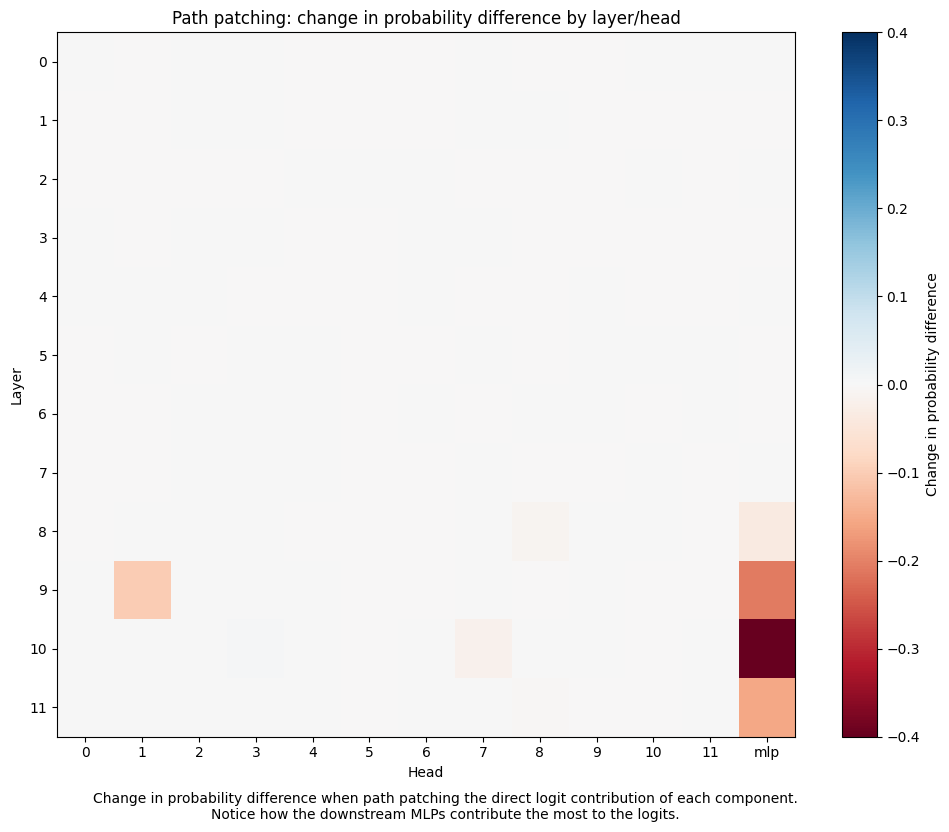

In [135]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(results.cpu().numpy(), cmap="RdBu", aspect="auto", vmin=-0.4, vmax=0.4)

ax.set_xlabel("Head")
ax.set_ylabel("Layer")

x_labels = [str(i) for i in range(12)] + ["mlp"]
ax.set_xticks(range(13))
ax.set_xticklabels(x_labels)
ax.set_yticks(range(12))

caption = "Change in probability difference when path patching the direct logit contribution of each component. Notice how the downstream MLPs contribute the most to the logits."
wrapped_caption = textwrap.fill(caption, width=100)

fig.text(0.45, -.03, wrapped_caption, ha='center', fontsize=10)


plt.colorbar(im, ax=ax, label="Change in probability difference")
plt.title("Path patching: change in probability difference by layer/head")
plt.tight_layout()
fig.savefig(f"figures/direct_logit_patch", dpi=150, bbox_inches="tight")
plt.show()

The direct logit path patching confirms our observations from week one that the circuit is largely MLP dependent. A natural next step is to discover which components contribute indirectly to the circuit through these later MLPs. Below we run more path patching through the path (component, MLP, logits) for MLPs 8, 9, 10, and 11. As with before, we consider all of the attention heads and MLPs upstream from the specified MLP as components to patch.

In [82]:
# Used to check tensor dimensions when computing patched MLP output
prompt = "The war lasted from the year 1802 to the year 18"

tokens = model.to_tokens(prompt)

_, cache = model.run_with_cache(tokens)
resid_mid = cache["resid_mid", 0]
print(resid_mid.size())

print(model.blocks[0].ln2)

print(model.blocks[0].mlp.W_in.size())
print(model.blocks[0].mlp.b_in.size())

print(model.blocks[0].mlp.W_out.size())

temp = model.blocks[0].ln2(resid_mid)

print(temp)

temp = torch.einsum('ijk, kl->ijl', resid_mid, model.blocks[0].mlp.W_in)
temp = temp + model.blocks[0].mlp.b_in
temp = F.gelu(temp)

temp = torch.einsum('ijk, kl->ijl', temp, model.blocks[0].mlp.W_out)
temp = temp + model.blocks[0].mlp.b_out

print(cache["resid_post",0].size())

print(temp.size())

torch.Size([1, 13, 768])
LayerNormPre(
  (hook_scale): HookPoint()
  (hook_normalized): HookPoint()
)
torch.Size([768, 3072])
torch.Size([3072])
torch.Size([3072, 768])
tensor([[[ 0.7464, -0.1910,  0.0773,  ..., -0.0055,  0.1420,  0.3190],
         [-0.1810,  0.1630, -0.5330,  ...,  0.0633, -0.0335,  0.1048],
         [ 0.3168, -0.7913,  0.0502,  ..., -0.1804, -0.1225, -0.1588],
         ...,
         [-0.0564,  0.3591,  0.0041,  ..., -0.1601,  0.0256, -0.1136],
         [ 0.6350,  0.4601, -0.0135,  ..., -0.1239, -0.0610, -0.0246],
         [-0.2182,  0.4842,  0.7017,  ...,  0.0172,  0.0091, -0.1572]]],
       device='mps:0')
torch.Size([1, 13, 768])
torch.Size([1, 13, 768])


In [91]:
def mlp_path_patch(layer, component, tokens, num, mlp, clean_cache, dirty_cache):
    """
        Performs path patching of ((layer, component), mlp, logits)
        to see which components contribute the most to the MLPs
        which do the actual greater than computation.

        Args:
            layer: the layer of the component we patch
            component: 0-12 where 12 is mlp
            mlp: the MLP that we patch through
            clean_cache: clean model cache
            dirty_cache: the cache of the corrupted input
        
        Return:
            Probability difference of the patched output
    """

    clean_mlp_out = clean_cache["mlp_out", mlp]
    clean_input = clean_cache["resid_mid", mlp]

    if (component == 12):
        clean_component = clean_cache["mlp_out", layer]
        dirty_component = dirty_cache["mlp_out", layer]
    else:
        clean_head_output = clean_cache["z", layer]
        dirty_head_output = dirty_cache["z", layer][:, :, component, :]

        modified_head_output = clean_head_output.clone() # Need to clone to not touch the clean cache
        modified_head_output[:, :, component, :] = dirty_head_output

        clean_component = clean_cache["attn_out", layer]
        dirty_component = (torch.einsum("bsnd,ndp->bsp",
                                        modified_head_output, model.blocks[layer].attn.W_O)
                           + model.blocks[layer].attn.b_O)

    # Patch the component's contribution into the MLP input
    patched_input = clean_input - clean_component + dirty_component

    # Run MLP forward on patched input
    patched_input = model.blocks[mlp].ln2(patched_input)
    dirty_mlp_out = torch.einsum('ijk, kl->ijl', patched_input, model.blocks[mlp].mlp.W_in) + model.blocks[mlp].mlp.b_in
    dirty_mlp_out = model.blocks[mlp].mlp.act_fn(dirty_mlp_out)
    dirty_mlp_out = torch.einsum('ijk, kl->ijl', dirty_mlp_out, model.blocks[mlp].mlp.W_out) + model.blocks[mlp].mlp.b_out

    # Swap out only the MLP's contribution in resid_post
    def mlp_patch_hook(value, hook):
        return value - clean_mlp_out + dirty_mlp_out

    logits = model.run_with_hooks(tokens, return_type="logits",
                                  fwd_hooks=[(f"blocks.{mlp}.hook_resid_post", mlp_patch_hook)])
    return prob_diff(logits, num)

In [ ]:
# Get dirty cache
with torch.no_grad():
    _, dirty_cache = model.run_with_cache(prompt_01)

In [110]:
# Start with MLP 11

# Accumulate results — outer loop over prompts to hold only one clean cache at a time
results_grid = torch.zeros(12, 13, device=device)

count = 0

with torch.no_grad():
    for k, (prompt, num) in enumerate(long_prompts):
        tokens = model.to_tokens(prompt)
        clean_logits, clean_cache = model.run_with_cache(prompt)
        clean_diff = prob_diff(clean_logits, num)
        del clean_logits

        for i in range(12):
            for j in range(13):
                patched_diff = mlp_path_patch(i, j, tokens, num, 11, clean_cache, dirty_cache)
                results_grid[i, j] += (patched_diff - clean_diff) / len(long_prompts)
        del clean_cache, tokens
        torch.mps.empty_cache()

results_11 = results_grid

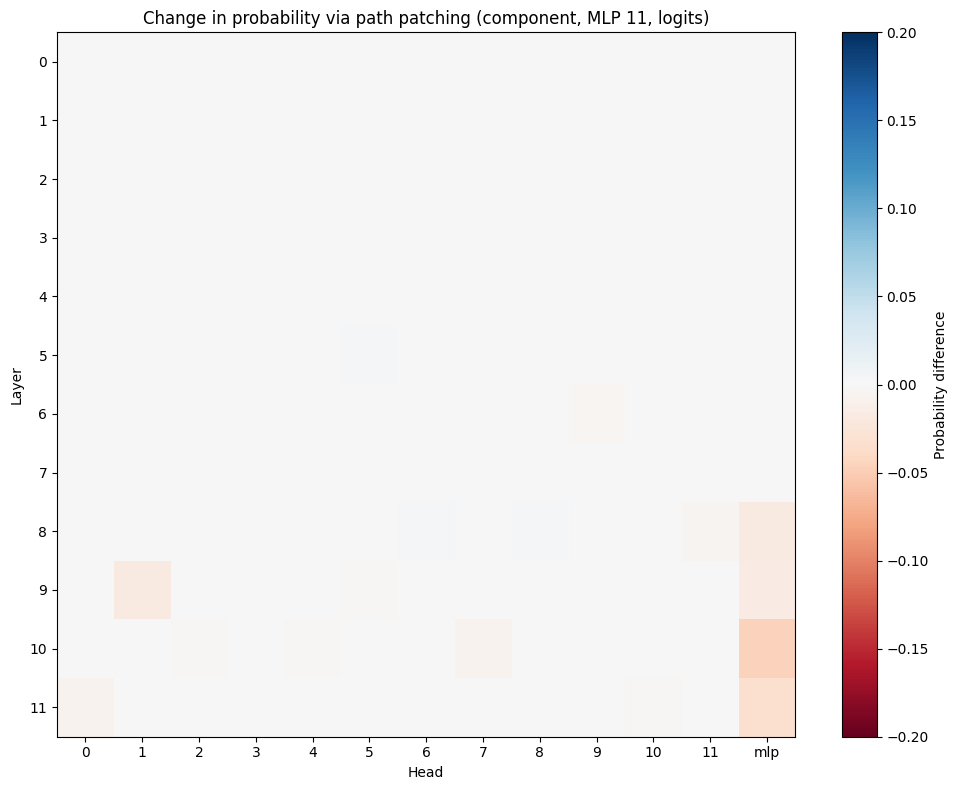

In [ ]:
# Visualize results for MLP 11

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(results_11.cpu().numpy(), cmap="RdBu", aspect="auto", vmin=-.2, vmax=.2)

ax.set_xlabel("Head")
ax.set_ylabel("Layer")

x_labels = [str(i) for i in range(12)] + ["mlp"]
ax.set_xticks(range(13))
ax.set_xticklabels(x_labels)
ax.set_yticks(range(12))

caption = "Change in probability difference when path patching through "
wrapped_caption = textwrap.fill(caption, width=80)

fig.text(0.45, -.03, wrapped_caption, ha='center', fontsize=10)

plt.colorbar(im, ax=ax, label="Probability difference")
plt.title("Change in probability via path patching (component, MLP 11, logits)")
plt.tight_layout()
fig.savefig(f"figures/mlp_11_path_patch", dpi=150, bbox_inches="tight")
plt.show()

In [115]:
# MLP 10

results_grid = torch.zeros(12, 13, device=device)

count = 0

with torch.no_grad():
    for k, (prompt, num) in enumerate(long_prompts):
        tokens = model.to_tokens(prompt)
        clean_logits, clean_cache = model.run_with_cache(prompt)
        clean_diff = prob_diff(clean_logits, num)
        del clean_logits

        for i in range(11):
            for j in range(13):
                patched_diff = mlp_path_patch(i, j, tokens, num, 10, clean_cache, dirty_cache)
                results_grid[i, j] += (patched_diff - clean_diff) / len(long_prompts)
        del clean_cache, tokens
        torch.mps.empty_cache()

results_10 = results_grid

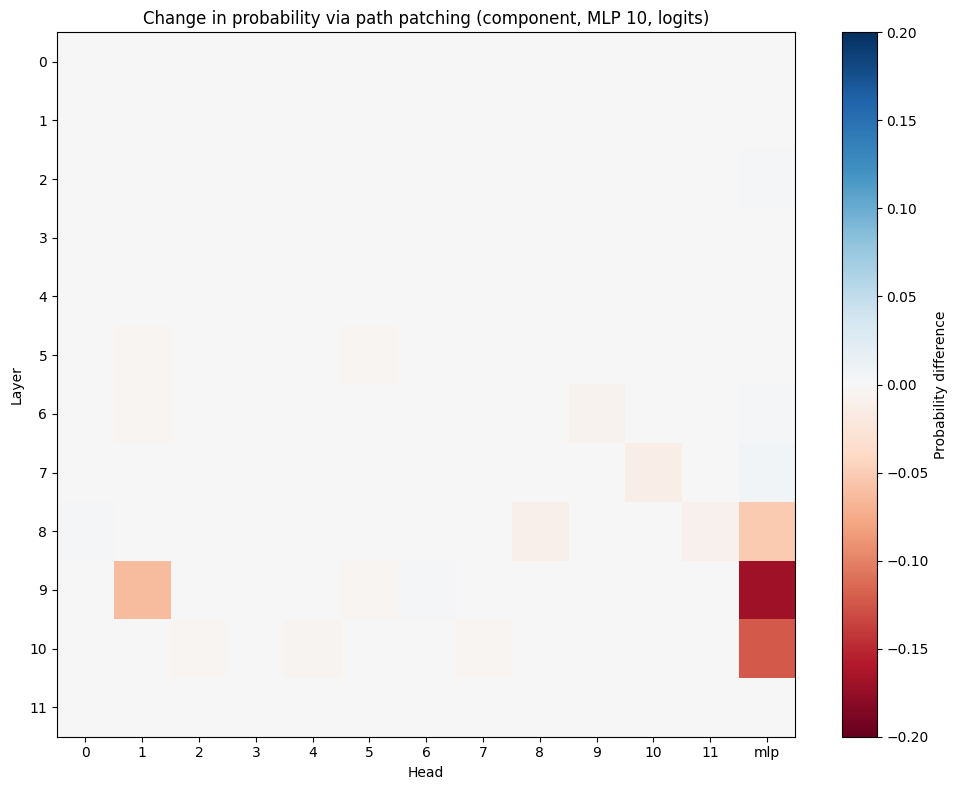

In [136]:
# Visualize results for MLP 10

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(results_10.cpu().numpy(), cmap="RdBu", aspect="auto", vmin=-.2, vmax=.2)

ax.set_xlabel("Head")
ax.set_ylabel("Layer")

x_labels = [str(i) for i in range(12)] + ["mlp"]
ax.set_xticks(range(13))
ax.set_xticklabels(x_labels)
ax.set_yticks(range(12))

plt.colorbar(im, ax=ax, label="Probability difference")
plt.title("Change in probability via path patching (component, MLP 10, logits)")
plt.tight_layout()
fig.savefig(f"figures/mlp_10_path_patch", dpi=150, bbox_inches="tight")
plt.show()

In [119]:
# MLP 9

results_grid = torch.zeros(12, 13, device=device)

count = 0

with torch.no_grad():
    for k, (prompt, num) in enumerate(long_prompts):
        tokens = model.to_tokens(prompt)
        clean_logits, clean_cache = model.run_with_cache(prompt)
        clean_diff = prob_diff(clean_logits, num)
        del clean_logits

        for i in range(10):
            for j in range(13):
                patched_diff = mlp_path_patch(i, j, tokens, num, 9, clean_cache, dirty_cache)
                results_grid[i, j] += (patched_diff - clean_diff) / len(long_prompts)
        del clean_cache, tokens
        torch.mps.empty_cache()

results_9 = results_grid

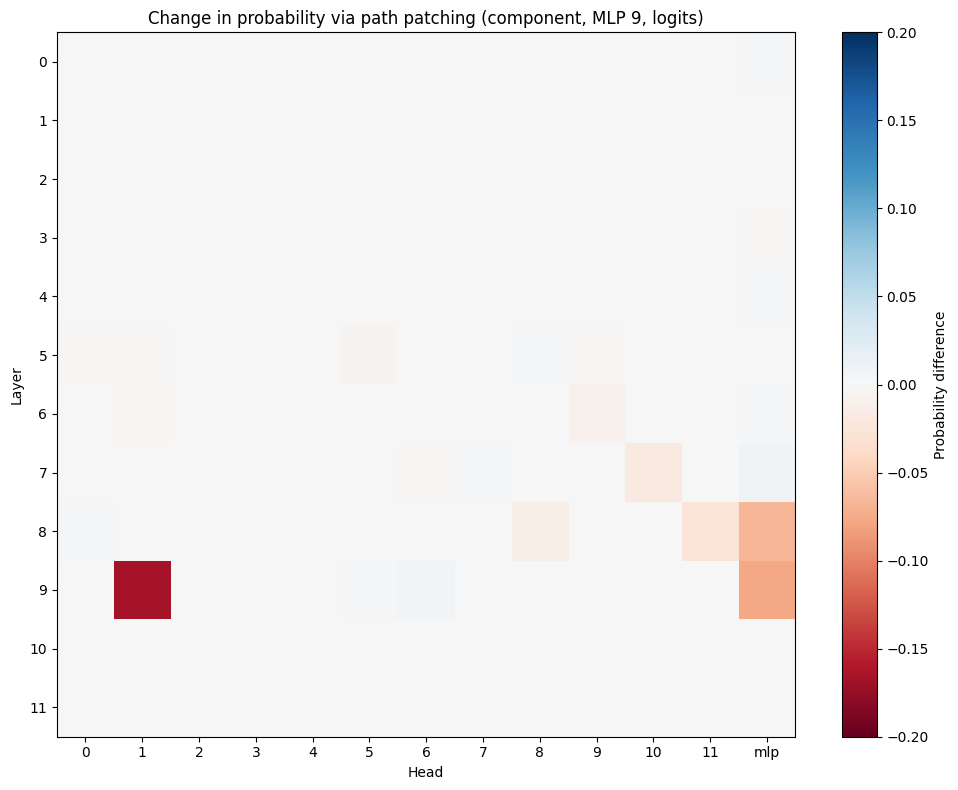

In [120]:
# Visualize results for MLP 9

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(results_9.cpu().numpy(), cmap="RdBu", aspect="auto", vmin=-.2, vmax=.2)

ax.set_xlabel("Head")
ax.set_ylabel("Layer")

x_labels = [str(i) for i in range(12)] + ["mlp"]
ax.set_xticks(range(13))
ax.set_xticklabels(x_labels)
ax.set_yticks(range(12))

plt.colorbar(im, ax=ax, label="Probability difference")
plt.title("Change in probability via path patching (component, MLP 9, logits)")
plt.tight_layout()
fig.savefig(f"figures/mlp_9_path_patch", dpi=150, bbox_inches="tight")
plt.show()

In [121]:
# MLP 8

results_grid = torch.zeros(12, 13, device=device)

count = 0

with torch.no_grad():
    for k, (prompt, num) in enumerate(long_prompts):
        tokens = model.to_tokens(prompt)
        clean_logits, clean_cache = model.run_with_cache(prompt)
        clean_diff = prob_diff(clean_logits, num)
        del clean_logits

        for i in range(9):
            for j in range(13):
                patched_diff = mlp_path_patch(i, j, tokens, num, 8, clean_cache, dirty_cache)
                results_grid[i, j] += (patched_diff - clean_diff) / len(long_prompts)
        del clean_cache, tokens
        torch.mps.empty_cache()

results_8 = results_grid

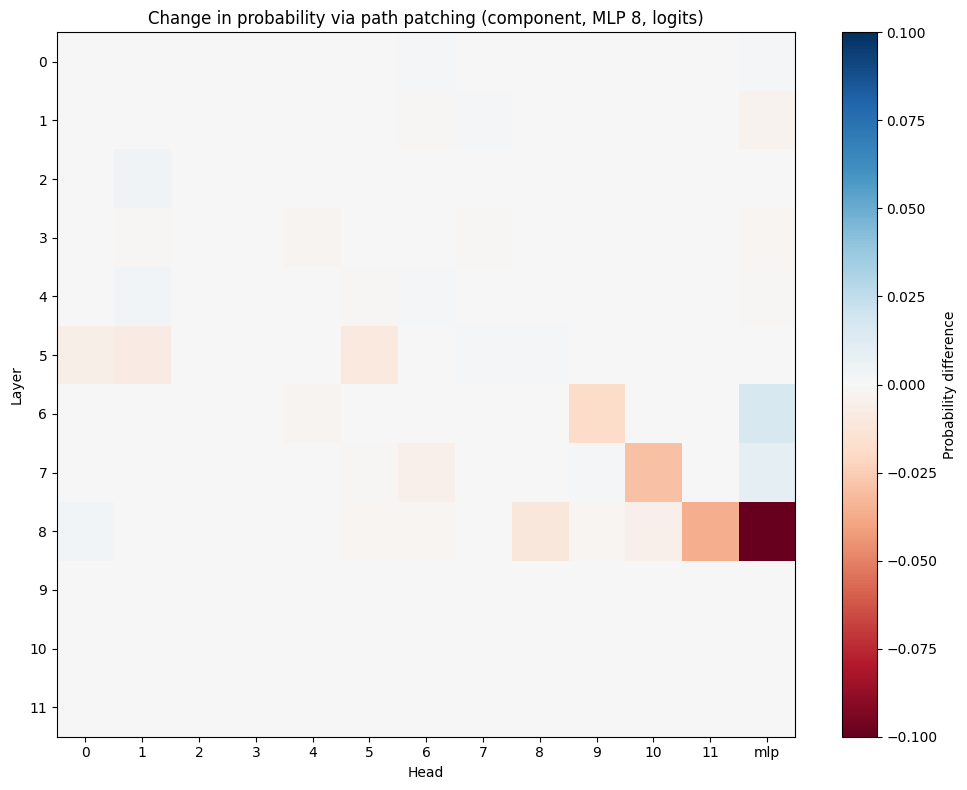

In [137]:
# Visualize results for MLP 9

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(results_8.cpu().numpy(), cmap="RdBu", aspect="auto", vmin=-.1, vmax=.1)

ax.set_xlabel("Head")
ax.set_ylabel("Layer")

x_labels = [str(i) for i in range(12)] + ["mlp"]
ax.set_xticks(range(13))
ax.set_xticklabels(x_labels)
ax.set_yticks(range(12))

plt.colorbar(im, ax=ax, label="Probability difference")
plt.title("Change in probability via path patching (component, MLP 8, logits)")
plt.tight_layout()
fig.savefig(f"figures/mlp_8_path_patch", dpi=150, bbox_inches="tight")
plt.show()